#### Libraries

In [58]:
import pandas as pd
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates
import numpy as np

#### Outlet-Level Thermal Analysis

**Goal:** Build an outlet-level, day-granular timeline across CTD, CLG, PLE, and Session logs to study thermal anomalies and PLE/CTD spikes.  

#### 1) Dataset schema audit
**Goal:** Inspect columns, dtypes and a few rows.  

In [107]:
# # 📁 Define paths
# DATA_DIR = os.path.join("..", "data")

# # 📥 Load datasets
# ctd_df = pd.read_excel(os.path.join(DATA_DIR, "CTD_total.xlsx"))
# clg_df = pd.read_excel(os.path.join(DATA_DIR, "CLG_total.xlsx"))
# ple_df = pd.read_excel(os.path.join(DATA_DIR, "PLE_timeseries.xlsx"))
# sess_df = pd.read_excel(os.path.join(DATA_DIR, "Sessend_Total.xlsx"))


# # 🔍 Function to summarize
# def summarize_dataset(name, df):
#     print(f"\n=== 🔎 {name} Dataset ===")
#     print("🧾 Columns:", df.columns.tolist())
#     print("📊 Dtypes:")
#     print(df.dtypes)
#     print("👀 Head:")
#     display(df.head(5))

# # 📥 Load and summarize each
# for name, df in [
#     ("CTD", ctd_df),
#     ("CLG", clg_df),
#     ("PLE", ple_df),
#     ("Sessend", sess_df)
# ]:
#     summarize_dataset(name, df)


#### 2) PLE: Extract outlet from @message
**Purpose:** Parse outlet id (DC1/DC2/…) from PLE logs.  

In [60]:
# 📁 Load dataset
DATA_DIR = os.path.join("..", "data")
ple_path = os.path.join(DATA_DIR, "PLE_timeseries.xlsx")
ple_df = pd.read_excel(ple_path)

# ✅ Step 1: Parse outlet info from `@message`
ple_df["outlet"] = ple_df["@message"].str.extract(r"(DC\d+)_CableTempSensor")

# 🔍 Optional check: Print unique outlets
print("✅ Extracted outlets:", ple_df["outlet"].dropna().unique())

# ✅ Step 2: Save the updated file back
ple_df.to_excel(ple_path, index=False)
print("✅ PLE_timeseries.xlsx updated with 'outlet' column.")


✅ Extracted outlets: ['DC1' 'DC2']
✅ PLE_timeseries.xlsx updated with 'outlet' column.


- 3) Normalize CTD outlets
**Purpose:** Extract integer outlet id from `cableid`.  
- 4) Normalize CLG outlets
**Purpose:** Extract integer outlet id from `cableid`.
- 5) Normalize PLE outlets
**Purpose:** Ensure integer `outlet` in PLE.  
- 6) Normalize Session outlets
**Purpose:** Strip quotes and parse `outlet` to integer.  

In [108]:
#3 Normalize CTD
def normalize_ctd(df):
    df["outlet"] = df["cableid"].str.extract(r"DC(\d+)").astype(float).astype("Int64")
    return df

ctd_df = normalize_ctd(ctd_df)

In [109]:
#4 Normalize CLG
def normalize_clg(df):
    df["outlet"] = pd.to_numeric(df["cableid"], errors="coerce").astype("Int64")
    return df

clg_df = normalize_clg(clg_df)

In [63]:
#5 Normalize PLE
def normalize_ple(df):
    if "outlet" not in df.columns:
        df["outlet"] = df["@message"].str.extract(r"(DC\d+)").iloc[:, 0]
    df["outlet"] = df["outlet"].str.extract(r"DC(\d+)").astype(float).astype("Int64")
    return df

ple_df = normalize_ple(ple_df)

In [64]:
#6 Normalize Sessions
def normalize_sessions(df):
    df["outlet"] = df["outlet"].astype(str).str.replace('"', '').str.extract(r"(\d+)").astype(float).astype("Int64")
    return df

sess_df = normalize_sessions(sess_df)

#### 7) Add day granularity
- All datasets now have a `day` column. Day-level aggregation reduces noise and aligns signals

In [65]:
#7 Add day column
for df in [ctd_df, clg_df, ple_df, sess_df]:
    df["@timestamp"] = pd.to_datetime(df["@timestamp"], errors='coerce')
    df["day"] = df["@timestamp"].dt.floor("D")

#### 8) Safety: sort timestamps
**Purpose:** Sort by `@timestamp` before merge. 

In [66]:
# After loading and timestamp conversion:
for df in [ctd_df, clg_df, ple_df, sess_df]:
    df["@timestamp"] = pd.to_datetime(df["@timestamp"], errors='coerce')
    df.sort_values(by="@timestamp", inplace=True)
    df["day"] = df["@timestamp"].dt.floor("D")

- 9) CTD aggregation: Purpose:** Aggregate CTD by outlet-day.  
- 10) CLG aggregation
- 11) PLE aggregation
- 12) Session aggregation

In [67]:
#9
ctd_summary = ctd_df.groupby(["@logStream", "outlet", "day"]).agg(
    CTD_count=("@timestamp", "count"),
    CTD_diff_mean=("diff", "mean"),
    CTD_factor_mean=("factor", "mean"),
    CTD_current_mean=("nowcur", "mean")
).reset_index()

In [68]:
print(ctd_summary.head())

  @logStream  outlet        day  CTD_count  CTD_diff_mean  CTD_factor_mean  \
0     D1HnIC       1 2025-01-23          2           5.05          0.13085   
1     D1HnIC       1 2025-01-24          1           5.00          0.05905   
2     D1HnIC       1 2025-01-25          1           5.00          0.07594   
3     D1HnIC       1 2025-01-29          1           5.00          0.04780   
4     D1HnIC       1 2025-01-30          1           5.10          0.06387   

   CTD_current_mean  
0             310.5  
1             398.0  
2             399.0  
3             364.0  
4             191.0  


In [69]:
#10
clg_summary = clg_df.groupby(["@logStream", "outlet", "day"]).agg(
    CLG_count=("@timestamp", "count"),
    CLG_diff_mean=("diff", "mean"),
    CLG_temp1_mean=("Contacttemp", "mean"),
    CLG_temp2_mean=("Contacttemp2", "mean"),
    CLG_current_mean=("nowcur", "mean")
).reset_index()

In [70]:
#11
ple_summary = ple_df.groupby(["@logStream", "outlet", "day"]).agg(
    PLE_count=("@timestamp", "count")
).reset_index()

In [71]:
#12 Re-aggregate Sessions with New features(Duration)
sess_summary = sess_df.groupby(["@logStream", "outlet", "day"]).agg(
    Sess_count=("@timestamp", "count"),
    Sess_energy_mean=("energy", "mean"),
    Sess_temp_diff_mean=("diff", "mean"),
    # NEW:
    Sess_duration_mean=("duration", "mean"),   # avg duration per day (e.g., seconds or minutes)
    Sess_duration_total=("duration", "sum")    # total duration per day
).reset_index()

In [110]:
# print(sess_summary.head())

#### 13) Build master logstream-outlet-timeline
**Purpose:** Merge CTD, CLG, PLE, Sessions on logstream-outlet-day.  

In [73]:
master_timeline = (
    ctd_summary.merge(clg_summary, on=["@logStream", "outlet", "day"], how="outer")
               .merge(ple_summary, on=["@logStream", "outlet", "day"], how="outer")
               .merge(sess_summary, on=["@logStream", "outlet", "day"], how="outer")
)

# Preview
print("✅ Outlet-normalized timeline built!")
print(master_timeline.shape)
display(master_timeline.head())

✅ Outlet-normalized timeline built!
(7318, 18)


,@logStream,outlet,day,CTD_count,CTD_diff_mean,CTD_factor_mean,CTD_current_mean,CLG_count,CLG_diff_mean,CLG_temp1_mean,CLG_temp2_mean,CLG_current_mean,PLE_count,Sess_count,Sess_energy_mean,Sess_temp_diff_mean,Sess_duration_mean,Sess_duration_total
0,D1HnIC,1,2024-07-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,30914.807692,1.345512,1467.692308,38160.0
1,D1HnIC,1,2024-07-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,19.0,31064.105263,2.332216,1539.210526,29245.0
2,D1HnIC,1,2024-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,35408.666667,1.675747,1670.400000,25056.0
3,D1HnIC,1,2024-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,36997.000000,1.719709,1641.636364,18058.0
4,D1HnIC,1,2024-07-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,22919.333333,1.986693,1121.800000,16827.0


- clean_master_timeline

- Counts (*_count) → fill missing with 0 (no event that day).

- Means (*_mean) → keep NaN (no measurement; don’t invent zeros).

- Make sure numeric columns are really numeric.

In [74]:
def clean_master_timeline(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- 1) Identify feature columns by suffix
    count_cols = [c for c in df.columns if c.endswith("_count")]
    mean_cols  = [c for c in df.columns if c.endswith("_mean")]

    # --- 2) Force numeric on feature columns (bad strings -> NaN)
    for c in count_cols + mean_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # --- 3) Fill counts with 0 (no event on that day)
    df[count_cols] = df[count_cols].fillna(0).astype("float64")

    # --- 4) Mask *means* by their family’s count (0 or NaN -> mean must be NaN)
    families = {
        "CTD": ["CTD_diff_mean", "CTD_factor_mean", "CTD_current_mean"],
        "CLG": ["CLG_diff_mean", "CLG_temp1_mean", "CLG_temp2_mean", "CLG_current_mean"],
        # PLE has only counts
    }

    for fam, cols in families.items():
        cnt = f"{fam}_count"
        if cnt in df.columns:
            mask = (df[cnt].isna()) | (df[cnt] == 0)
            for col in cols:
                if col in df.columns:
                    # Any day with count==0/NaN cannot have a valid mean -> set to NaN
                    df.loc[mask, col] = np.nan

    # --- 5) Ensure key columns typed correctly
    if "@timestamp" in df.columns:
        df["@timestamp"] = pd.to_datetime(df["@timestamp"], errors="coerce")
    if "day" in df.columns:
        df["day"] = pd.to_datetime(df["day"], errors="coerce")
    if "outlet" in df.columns:
        df["outlet"] = pd.to_numeric(df["outlet"], errors="coerce").astype("Int64")

    return df

# 👉 apply right after the outer merges
master_timeline = clean_master_timeline(master_timeline)

print("✅ Cleaned + masked timeline.")
print("Counts (zero-filled):", [c for c in master_timeline.columns if c.endswith("_count")])
print("Means (masked by counts):", [c for c in master_timeline.columns if c.endswith("_mean")])

✅ Cleaned + masked timeline.
Counts (zero-filled): ['CTD_count', 'CLG_count', 'PLE_count', 'Sess_count']
Means (masked by counts): ['CTD_diff_mean', 'CTD_factor_mean', 'CTD_current_mean', 'CLG_diff_mean', 'CLG_temp1_mean', 'CLG_temp2_mean', 'CLG_current_mean', 'Sess_energy_mean', 'Sess_temp_diff_mean', 'Sess_duration_mean']


- convert ms -> minutes BEFORE grouping


In [75]:
#convert ms -> minutes BEFORE grouping
sess_df["duration"] = pd.to_numeric(sess_df["duration"], errors="coerce")
sess_df["duration_min"] = sess_df["duration"] / 60000.0  # ms to minutes
# then aggregate on "duration_min" instead of "duration"

In [76]:
print(master_timeline.shape)
display(master_timeline.head(400))

(7318, 18)


,@logStream,outlet,day,CTD_count,CTD_diff_mean,CTD_factor_mean,CTD_current_mean,CLG_count,CLG_diff_mean,CLG_temp1_mean,CLG_temp2_mean,CLG_current_mean,PLE_count,Sess_count,Sess_energy_mean,Sess_temp_diff_mean,Sess_duration_mean,Sess_duration_total
0,D1HnIC,1,2024-07-26,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,26.0,30914.807692,1.345512,1467.692308,38160.0
1,D1HnIC,1,2024-07-27,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.0,19.0,31064.105263,2.332216,1539.210526,29245.0
2,D1HnIC,1,2024-07-28,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,15.0,35408.666667,1.675747,1670.400000,25056.0
3,D1HnIC,1,2024-07-29,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,11.0,36997.000000,1.719709,1641.636364,18058.0
4,D1HnIC,1,2024-07-30,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,15.0,22919.333333,1.986693,1121.800000,16827.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,D1HnIC,2,2024-09-19,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,1.0,24767.000000,0.518300,1815.000000,1815.0
396,D1HnIC,2,2024-09-20,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,5.0,35038.600000,2.695000,1618.400000,8092.0
397,D1HnIC,2,2024-09-21,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,4.0,26579.750000,6.996625,1299.000000,5196.0
398,D1HnIC,2,2024-09-23,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,4.0,37697.750000,1.943525,1254.000000,5016.0


#### 14) Completeness check
**Purpose:** Count NaNs per feature.  

In [77]:
# 📝 List of columns to check
columns_to_check = [
   "CTD_count","CLG_count","PLE_count", "Sess_count"
]

# 🔍 Count zeros in each
zero_counts = (master_timeline[columns_to_check] == 0).sum()

# 🔢 Also show total number of rows for reference
total_rows = len(master_timeline)

# 🖨️ Print report
print(f"Total rows: {total_rows}\n")
for col in columns_to_check:
    count = int(zero_counts[col])
    pct = round(100 * count / total_rows, 2) if total_rows else 0
    if count == total_rows:
        print(f"⚠️ Column '{col}' has ALL {count} zeros ❗")
    else:
        print(f"✅ Column '{col}' has {count} zeros ({pct}%)")


Total rows: 7318

✅ Column 'CTD_count' has 5337 zeros (72.93%)
✅ Column 'CLG_count' has 6939 zeros (94.82%)
✅ Column 'PLE_count' has 6060 zeros (82.81%)
✅ Column 'Sess_count' has 270 zeros (3.69%)


- Why did Sess_count become 0?
- In the outer merge, if on a given day + charger + outlet there were no sessions recorded, the merged row is created anyway (due to CTD/CLG/PLE presence, or just the calendar alignment).

In [78]:
# Investigate rows where Sess_count == 0
sess_zero = master_timeline[master_timeline["Sess_count"] == 0]

print("Number of Sess_count == 0 rows:", len(sess_zero))
print("\nUnique chargers with Sess_count == 0:")
print(sess_zero["@logStream"].unique())

print("\nDate range of Sess_count == 0 rows:")
print(sess_zero["day"].min(), "->", sess_zero["day"].max())

# Show some sample rows
display(sess_zero.head(270))

Number of Sess_count == 0 rows: 270

Unique chargers with Sess_count == 0:
['D1HnIC' 'XnvqOe' 'aJbfMb' 'mgibgC' 'rn5pA9' 'zhSxBz']

Date range of Sess_count == 0 rows:
2024-07-28 00:00:00 -> 2025-07-25 00:00:00


,@logStream,outlet,day,CTD_count,CTD_diff_mean,CTD_factor_mean,CTD_current_mean,CLG_count,CLG_diff_mean,CLG_temp1_mean,CLG_temp2_mean,CLG_current_mean,PLE_count,Sess_count,Sess_energy_mean,Sess_temp_diff_mean,Sess_duration_mean,Sess_duration_total
225,D1HnIC,1,2025-03-27,0.0,NaN,NaN,NaN,27.0,3.051852,59.029630,56.274074,215.333333,0.0,0.0,NaN,NaN,NaN,NaN
2825,XnvqOe,1,2025-06-28,0.0,NaN,NaN,NaN,16.0,0.456250,79.300000,79.756250,291.812500,0.0,0.0,NaN,NaN,NaN,NaN
2826,XnvqOe,1,2025-06-29,0.0,NaN,NaN,NaN,10.0,2.220000,82.130000,79.910000,320.300000,0.0,0.0,NaN,NaN,NaN,NaN
2829,XnvqOe,1,2025-07-13,0.0,NaN,NaN,NaN,7.0,1.914286,81.742857,79.828571,314.857143,0.0,0.0,NaN,NaN,NaN,NaN
2830,XnvqOe,1,2025-07-20,0.0,NaN,NaN,NaN,7.0,1.914286,81.742857,79.828571,314.857143,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,rn5pA9,2,2025-07-14,1.0,5.0,0.2272,235.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6310,rn5pA9,2,2025-07-15,1.0,5.1,0.1542,249.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6311,rn5pA9,2,2025-07-21,1.0,5.1,0.1555,247.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6844,zhSxBz,1,2025-03-03,0.0,NaN,NaN,NaN,8.0,4.962500,74.000000,78.962500,317.250000,0.0,0.0,NaN,NaN,NaN,NaN


In [79]:
print(master_timeline.shape)
display(master_timeline.head(7000))

(7318, 18)


,@logStream,outlet,day,CTD_count,CTD_diff_mean,CTD_factor_mean,CTD_current_mean,CLG_count,CLG_diff_mean,CLG_temp1_mean,CLG_temp2_mean,CLG_current_mean,PLE_count,Sess_count,Sess_energy_mean,Sess_temp_diff_mean,Sess_duration_mean,Sess_duration_total
0,D1HnIC,1,2024-07-26,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,26.0,30914.807692,1.345512,1467.692308,38160.0
1,D1HnIC,1,2024-07-27,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.0,19.0,31064.105263,2.332216,1539.210526,29245.0
2,D1HnIC,1,2024-07-28,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,15.0,35408.666667,1.675747,1670.400000,25056.0
3,D1HnIC,1,2024-07-29,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,11.0,36997.000000,1.719709,1641.636364,18058.0
4,D1HnIC,1,2024-07-30,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,15.0,22919.333333,1.986693,1121.800000,16827.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,zhSxBz,2,2024-08-08,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,8.0,31665.375000,3.271575,1323.500000,10588.0
6996,zhSxBz,2,2024-08-09,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,10.0,40286.200000,1.477070,1857.400000,18574.0
6997,zhSxBz,2,2024-08-10,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,21.0,40520.571429,1.122924,1853.904762,38932.0
6998,zhSxBz,2,2024-08-11,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,10.0,53390.600000,1.088370,2246.000000,22460.0


- 15) Alias timeline

In [80]:
outlet_timeline = master_timeline  

#### 16) Feature availability over time

In [81]:
# # 🔢 Count number of non-NaN entries per column per day
# availability_by_day = (
#     outlet_timeline
#     .groupby("day")[[
#         "CTD_count", "CLG_count", "PLE_count",
#         "Sess_count", "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_duration_mean"
#     ]]
#     .apply(lambda x: x.notna().sum())
# )

# # Plot
# plt.figure(figsize=(18, 6))
# for col in availability_by_day.columns:
#     plt.plot(availability_by_day.index, availability_by_day[col], marker='o', label=col)

# plt.title("Feature Availability Over Time")
# plt.xlabel("Date")
# plt.ylabel("Available Records")
# plt.xticks(rotation=45)
# plt.legend()
# plt.tight_layout()
# plt.show()


#### 17) Heatmap per charger-outlet
**Purpose:** Visualize coverage across features.  
**Why:** Identify strong outlets for deep-dives.  

In [82]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # --- Build a single matrix: Active days per feature + one "Coverage" column ---

# # Helper that counts "active" days (>0) for a numeric series (handles NaN safely)
# def active_days(s: pd.Series) -> int:
#     s = pd.to_numeric(s, errors="coerce").fillna(0)
#     return (s > 0).sum()

# g = outlet_timeline.groupby(["@logStream", "outlet"], dropna=False)

# # Per-feature ACTIVE days
# act = g.agg(
#     CLG_active=("CLG_count", active_days),
#     CTD_active=("CTD_count", active_days),
#     PLE_active=("PLE_count", active_days),
# )

# # One unified COVERAGE column (days where ANY of the features had a recorded value)
# # You can include Sess_count in the union if you want; here we use the three debug-driven features.
# cols_for_coverage = ["CLG_count", "CTD_count", "PLE_count", "Sess_count"]  # include sessions in coverage
# mask_any = (
#     outlet_timeline[cols_for_coverage]
#     .apply(pd.to_numeric, errors="coerce")
#     .notna()
#     .any(axis=1)
# )

# coverage = (
#     mask_any.groupby([outlet_timeline["@logStream"], outlet_timeline["outlet"]])
#     .sum()
#     .rename("Coverage")
#     .to_frame()
# )

# # Merge into one matrix for plotting
# mat = (
#     act.join(coverage, how="left")
#        .fillna(0)
#        .astype(int)
#        .sort_index()
# )

# # Plot a single heatmap
# plt.figure(figsize=(14, 7))
# sns.heatmap(mat, annot=True, fmt=".0f", cmap="YlOrRd")
# plt.title("Feature Activity (days > 0) + Coverage per Charger–Outlet", fontsize=14)
# plt.xlabel("Metric")
# plt.ylabel("Charger – Outlet")
# plt.tight_layout()
# plt.show()


#### 18) Deep-dive: `Q2MW2c` – outlet 2

In [84]:
# print(outlet_timeline.columns.tolist())
# print(outlet_timeline[["Sess_energy_mean", "Sess_count"]].head(10))


In [113]:
# === Outlier capping helper (already added earlier) ===
def cap_outliers(series, upper_quantile=0.99):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return s
    cap_value = s.quantile(upper_quantile)
    return np.minimum(s, cap_value)

# === Trend helper (as before) ===
def _add_trends(ax, x_dates, y, rolling_window=21, base_color="C0", label="Series"):
    ax.plot(x_dates, y, marker='o', linestyle='-', color=base_color, label=label)
    y_roll = pd.Series(y, index=pd.to_datetime(x_dates)).rolling(
        window=rolling_window, min_periods=1
    ).mean().values
    ax.plot(
        x_dates, y_roll, linestyle='--', linewidth=2,
        color="black" if base_color in ("green","orange","blue","purple","red") else base_color,
        label=f"Trend ({rolling_window}d rolling)"
    )

# === Updated deep-dive plot: add Sess_duration_mean panel ===
def plot_outlet_with_trends(outlet_timeline, charger, outlet, rolling_window=30, duration_unit_label="min"):
    df = outlet_timeline[(outlet_timeline["@logStream"] == charger) &
                         (outlet_timeline["outlet"] == outlet)].copy()
    if df.empty:
        print("No data for this charger/outlet.")
        return

    df = df.sort_values("day")
    df["day"] = pd.to_datetime(df["day"])

    # New Feature: Energy per Session
    df["Energy_per_session"] = np.where(
        df["Sess_count"] > 0,
        df["Sess_energy_mean"] / df["Sess_count"],
        np.nan
    )

    # Cap outliers (per-feature thresholds)
    if "Energy_per_session" in df:
        df["Energy_per_session"] = cap_outliers(df["Energy_per_session"], 0.95)
    if "Sess_temp_diff_mean" in df:
        df["Sess_temp_diff_mean"] = cap_outliers(df["Sess_temp_diff_mean"], 0.99)
    if "PLE_count" in df:
        df["PLE_count"] = cap_outliers(df["PLE_count"], 0.99)
    if "CTD_count" in df:
        df["CTD_count"] = cap_outliers(df["CTD_count"], 0.99)
    if "Sess_duration_mean" in df:
        # Duration can be very skewed; cap a bit stronger
        df["Sess_duration_mean"] = cap_outliers(df["Sess_duration_mean"], 0.95)

    # --- 5 panels: Energy/Session, Temp Diff, Duration, PLE, CTD ---
    fig, axs = plt.subplots(5, 1, figsize=(18, 17), sharex=True)
    fig.suptitle(f"Timeline with Trends: {charger} – Outlet {outlet}", fontsize=16)

    # 1) Energy per Session
    _add_trends(axs[0], df["day"], df["Energy_per_session"].to_numpy(dtype=float),
                rolling_window, base_color="green", label="Wh/Session")
    axs[0].set_title("Energy per Session (Wh/Session)")
    axs[0].set_ylabel("Wh/Session"); axs[0].legend(loc="upper left")

    # 2) Session Temp Diff
    _add_trends(axs[1], df["day"], df["Sess_temp_diff_mean"].to_numpy(dtype=float),
                rolling_window, base_color="orange", label="Temp Diff (°C)")
    axs[1].set_title("Session Temperature Diff (°C)")
    axs[1].set_ylabel("°C"); axs[1].legend(loc="upper left")

    # 3) Session Duration (mean)
    if "Sess_duration_mean" in df:
        _add_trends(axs[2], df["day"], df["Sess_duration_mean"].to_numpy(dtype=float),
                    rolling_window, base_color="purple", label=f"Duration ({duration_unit_label})")
        axs[2].set_title(f"Session Duration (mean, {duration_unit_label})")
        axs[2].set_ylabel(duration_unit_label); axs[2].legend(loc="upper left")
    else:
        axs[2].set_title("Session Duration (mean)")
        axs[2].text(0.5, 0.5, "No duration data", ha='center', va='center', transform=axs[2].transAxes)

    # 4) PLE Count
    _add_trends(axs[3], df["day"], df["PLE_count"].to_numpy(dtype=float),
                rolling_window, base_color="blue", label="PLE Count")
    axs[3].set_title("PLE Count")
    axs[3].set_ylabel("count"); axs[3].legend(loc="upper left")

    # 5) CTD Count
    if df["CTD_count"].notna().sum() > 0:
        _add_trends(axs[4], df["day"], df["CTD_count"].to_numpy(dtype=float),
                    rolling_window, base_color="brown", label="CTD Count")
    else:
        axs[4].text(0.5, 0.5, "No CTD data available", ha='center', va='center', transform=axs[4].transAxes)
    axs[4].set_title("CTD Count")
    axs[4].set_ylabel("count"); axs[4].legend(loc="upper left")

    # X-axis
    axs[4].xaxis.set_major_locator(mdates.MonthLocator())
    axs[4].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


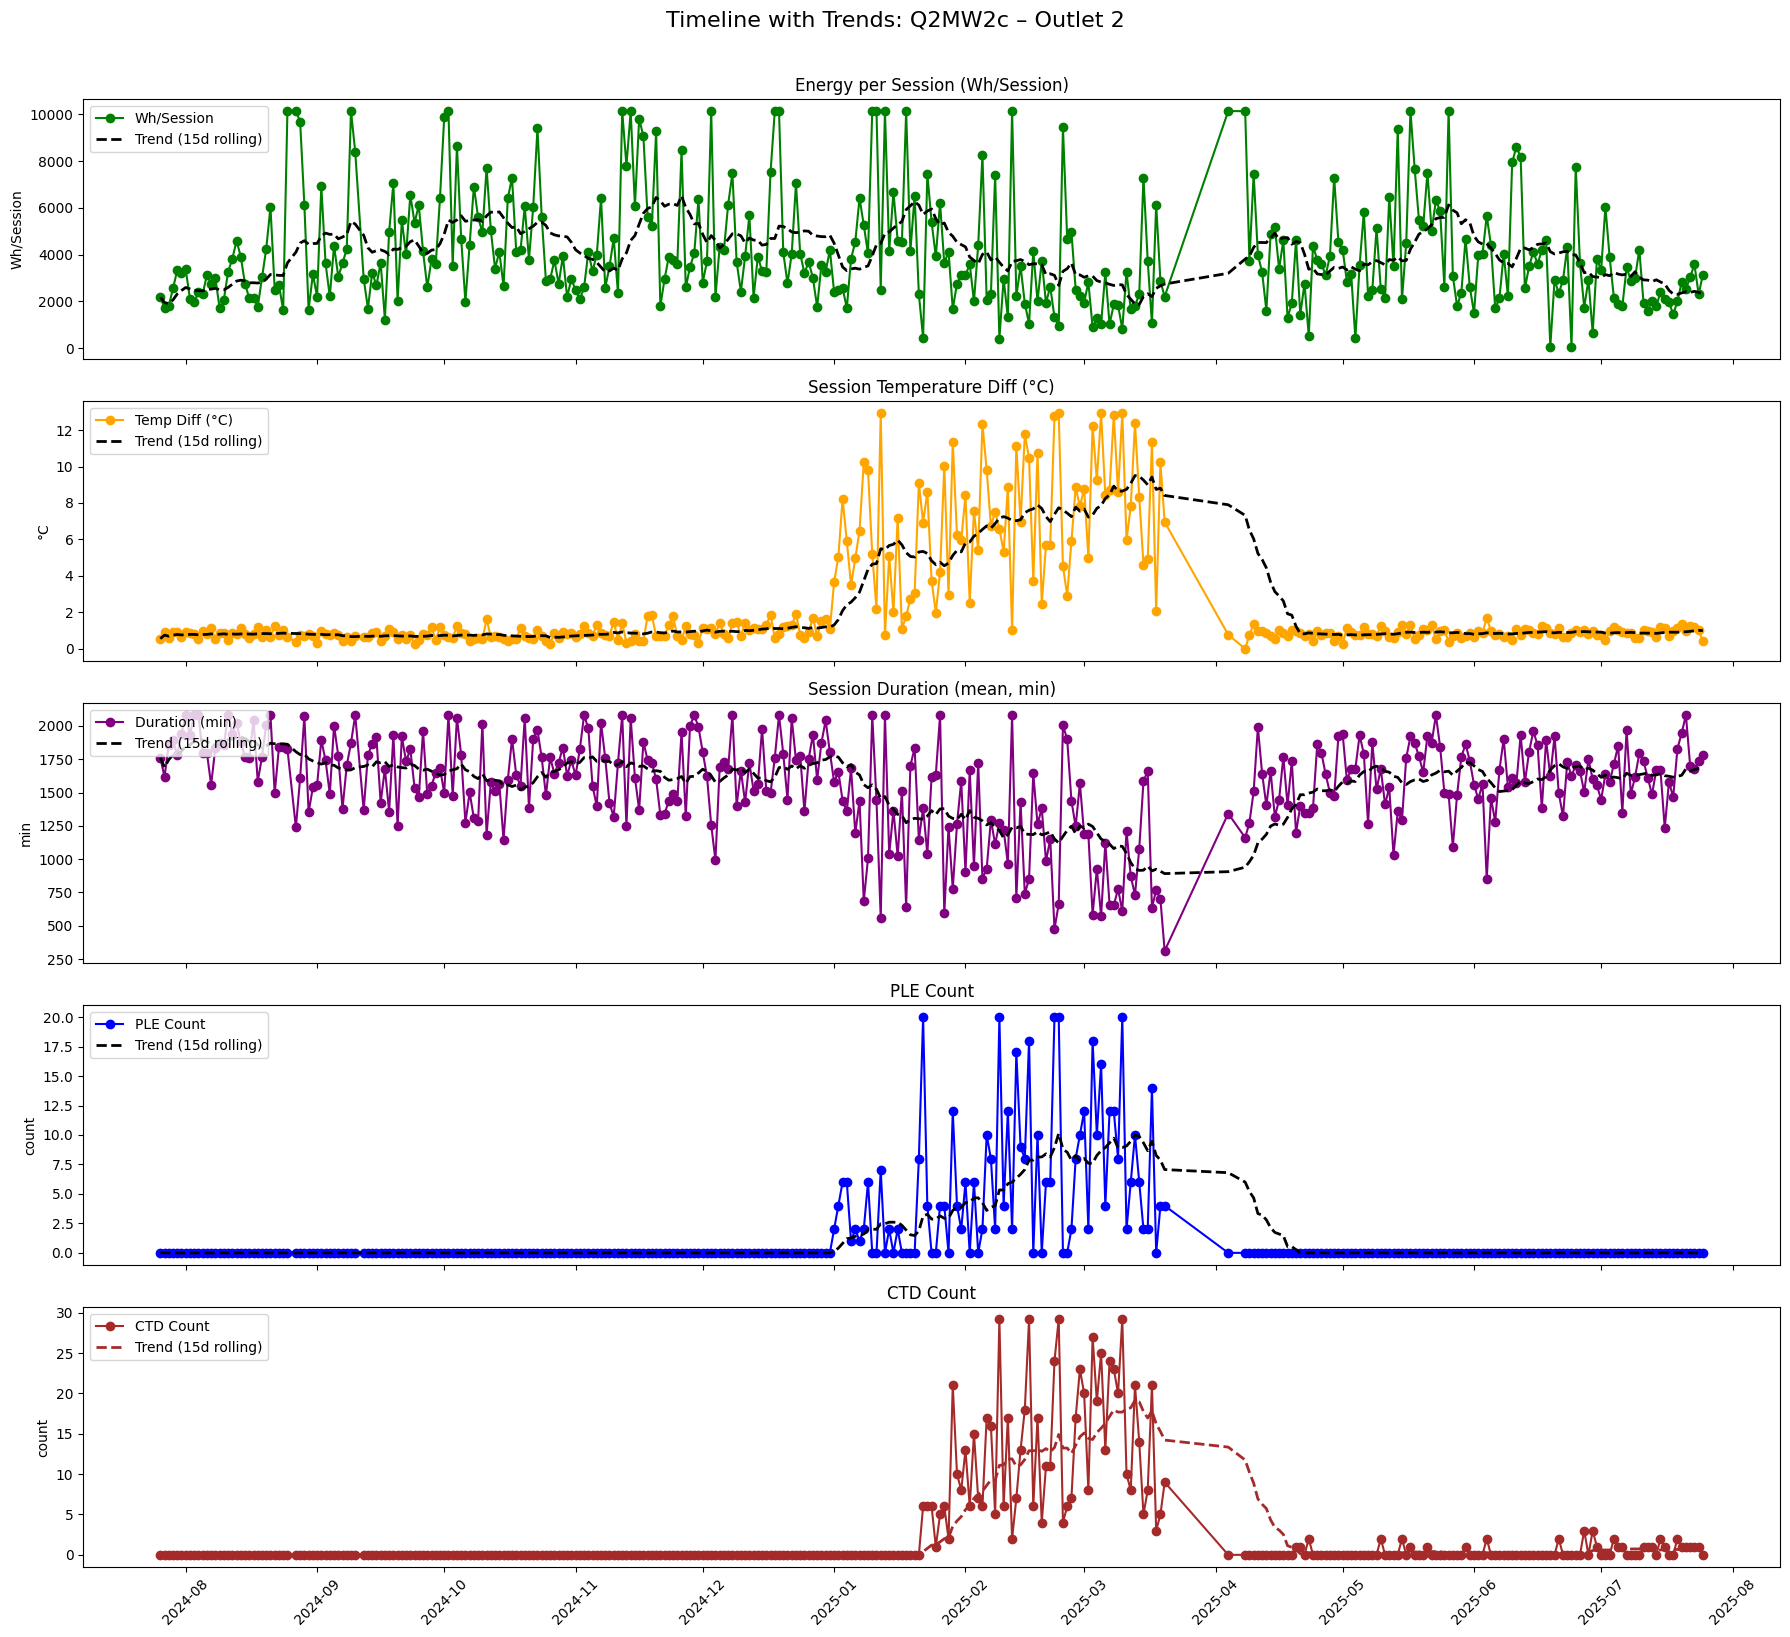

In [114]:
# ==== Run for chosen outlet ====
plot_outlet_with_trends(outlet_timeline, charger="Q2MW2c", outlet=2, rolling_window=15)

#### 20) Batch export plots - All outlets
- Auto-save PNG per charger-outlet.  

In [116]:
# === Batch export plots with Energy/Session + Duration ===
def export_all_outlets_with_trends(outlet_timeline,
                                               output_dir="../plots_outlet_timelines",
                                               rolling_window=30,
                                               duration_unit_label="min"):
    import os
    os.makedirs(output_dir, exist_ok=True)

    for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
        if df.empty:
            continue

        df = df.sort_values("day").copy()
        df["day"] = pd.to_datetime(df["day"], errors="coerce")

        # New Feature: Energy per Session
        df["Energy_per_session"] = np.where(
            df["Sess_count"] > 0,
            df["Sess_energy_mean"] / df["Sess_count"],
            np.nan
        )

        # Apply outlier capping
        if "Energy_per_session" in df:
            df["Energy_per_session"] = cap_outliers(df["Energy_per_session"], 0.95)
        if "Sess_temp_diff_mean" in df:
            df["Sess_temp_diff_mean"] = cap_outliers(df["Sess_temp_diff_mean"], 0.99)
        if "PLE_count" in df:
            df["PLE_count"] = cap_outliers(df["PLE_count"], 0.99)
        if "CTD_count" in df:
            df["CTD_count"] = cap_outliers(df["CTD_count"], 0.99)
        if "Sess_duration_mean" in df:
            df["Sess_duration_mean"] = cap_outliers(df["Sess_duration_mean"], 0.95)

        # --- Use same panel layout as deep-dive ---
        fig, axs = plt.subplots(5, 1, figsize=(18, 17), sharex=True)
        fig.suptitle(f"Timeline with Trends: {charger} – Outlet {outlet}", fontsize=16)

        _add_trends(axs[0], df["day"], df["Energy_per_session"].to_numpy(dtype=float),
                    rolling_window, base_color="green", label="Wh/Session")
        axs[0].set_title("Energy per Session (Wh/Session)")
        axs[0].set_ylabel("Wh/Session"); axs[0].legend(loc="upper left")

        _add_trends(axs[1], df["day"], df["Sess_temp_diff_mean"].to_numpy(dtype=float),
                    rolling_window, base_color="orange", label="Temp Diff (°C)")
        axs[1].set_title("Session Temperature Diff (°C)")
        axs[1].set_ylabel("°C"); axs[1].legend(loc="upper left")

        if "Sess_duration_mean" in df:
            _add_trends(axs[2], df["day"], df["Sess_duration_mean"].to_numpy(dtype=float),
                        rolling_window, base_color="purple", label=f"Duration ({duration_unit_label})")
            axs[2].set_title(f"Session Duration (mean, {duration_unit_label})")
            axs[2].set_ylabel(duration_unit_label); axs[2].legend(loc="upper left")
        else:
            axs[2].text(0.5, 0.5, "No duration data", ha='center', va='center', transform=axs[2].transAxes)

        _add_trends(axs[3], df["day"], df["PLE_count"].to_numpy(dtype=float),
                    rolling_window, base_color="blue", label="PLE Count")
        axs[3].set_title("PLE Count")
        axs[3].set_ylabel("count"); axs[3].legend(loc="upper left")

        if df["CTD_count"].notna().sum() > 0:
            _add_trends(axs[4], df["day"], df["CTD_count"].to_numpy(dtype=float),
                        rolling_window, base_color="brown", label="CTD Count")
        else:
            axs[4].text(0.5, 0.5, "No CTD data available", ha='center', va='center', transform=axs[4].transAxes)
        axs[4].set_title("CTD Count")
        axs[4].set_ylabel("count"); axs[4].legend(loc="upper left")

        axs[4].xaxis.set_major_locator(mdates.MonthLocator())
        axs[4].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.xticks(rotation=45)

        plt.tight_layout(rect=[0, 0.02, 1, 0.97])

        # Save plot instead of show
        filename = f"{charger}_Outlet{outlet}_energy_duration.png".replace("/", "_")
        plt.savefig(os.path.join(output_dir, filename), dpi=150)
        plt.close(fig)

    print(f"✅ Batch export done: plots with Energy/Session + Duration saved to {output_dir}")


In [121]:
export_all_outlets_with_trends(outlet_timeline,
                                            output_dir="../plots_outlet_timelines",
                                            rolling_window=30,
                                            duration_unit_label="min")

✅ Batch export done: plots with Energy/Session + Duration saved to ../plots_outlet_timelines


 #### 21) Correlation Matrix for One Charger-Outlet

- How to judge the numbers_

0.6 to 1.0 (or -0.6 to -1.0) → strong correlation.

0.4 to 0.6 (or -0.4 to -0.6) → moderate correlation.

0.2 to 0.4 (or -0.2 to -0.4) → weak correlation.

0.0 to 0.2 → very little or no correlation.

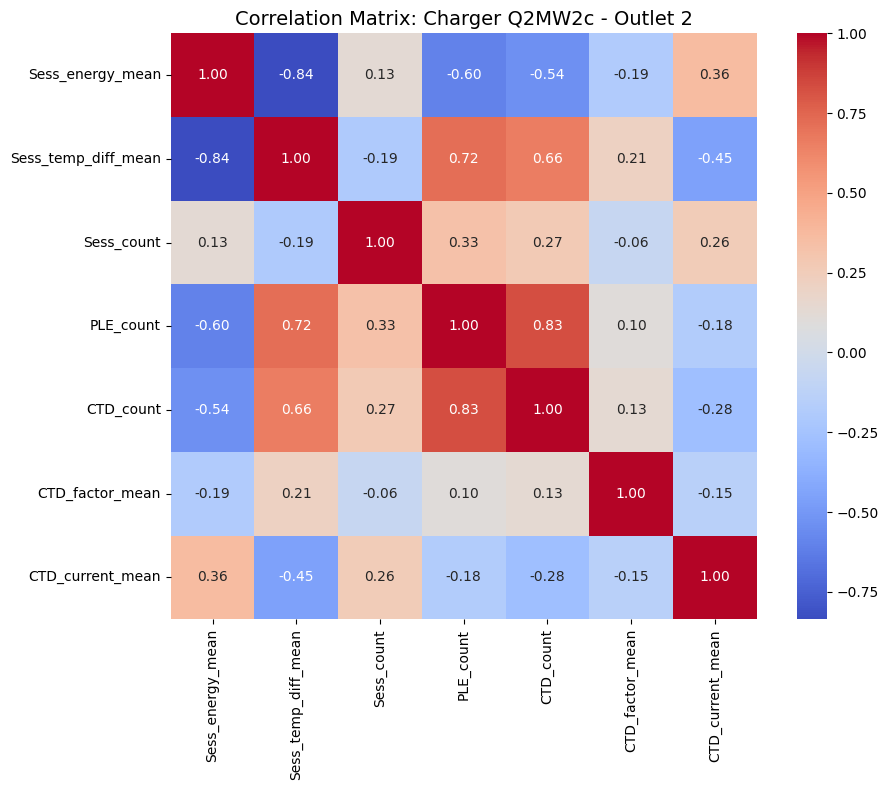

In [88]:
# --- Correlation Matrix for One Charger-Outlet ---
# 🎯 Filter data for the charger-outlet of interest
charger = "Q2MW2c"
outlet = 2
df = outlet_timeline[
    (outlet_timeline["@logStream"] == charger) &
    (outlet_timeline["outlet"] == outlet)
].copy()

# 🧹 Keep only numeric feature columns
numeric_cols = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count",
    "CTD_count", "CTD_factor_mean", "CTD_current_mean",
    "CLG_temp1_mean", "CLG_temp2_mean", "CLG_diff_mean", "CLG_current_mean"
]

# Drop columns with all NaNs
df_num = df[numeric_cols].dropna(axis=1, how="all")

# Drop rows with too many NaNs (optional, keeps correlations valid)
df_num = df_num.dropna(how="any")

# 📊 Compute correlation matrix
corr = df_num.corr(method="pearson")

# 🔥 Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title(f"Correlation Matrix: Charger {charger} - Outlet {outlet}", fontsize=14)
plt.tight_layout()
plt.show()


#### Correlation Matrix for all Chargers-Outlets

In [89]:
# 📁 Output folder
output_dir_corr = "../plots_outlet_correlations"
os.makedirs(output_dir_corr, exist_ok=True)

# 🎯 Features to analyze
features = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count", "CTD_count", "CTD_factor_mean", "CTD_current_mean"
]

# 🔄 Iterate over each charger-outlet
for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    df = df[features].dropna(how="all")  # keep only relevant columns

    if df.empty:
        continue  # skip if no data

    # 📊 Correlation matrix
    corr = df.corr()

    # 🎨 Plot heatmap
    plt.figure(figsize=(8, 7))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix: {charger} - Outlet {outlet}", fontsize=14)

    # 💾 Save each plot
    filename = f"{charger}_Outlet{outlet}_correlation.png".replace("/", "_")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_corr, filename), dpi=150)
    plt.close()

print(f"✅ Correlation matrices saved in {output_dir_corr}")


✅ Correlation matrices saved in ../plots_outlet_correlations


#### Export Correlation Values for All Chargers/Outlets
- which chargers/outlets are worth keeping

In [90]:
# 🎯 Features we care about
features = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count", "CTD_count", "CTD_factor_mean", "CTD_current_mean"
]

# 📊 Store results here
correlation_records = []

# 🔄 Iterate through charger-outlet pairs
for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    df = df[features].dropna(how="all")  # keep only numeric data

    if df.shape[0] < 10:  
        continue  # skip outlets with too few rows to be meaningful

    # Compute correlation matrix
    corr = df.corr()

    # Flatten into long format for CSV
    for row in corr.index:
        for col in corr.columns:
            if row != col:  # skip self-correlation (always 1.0)
                correlation_records.append({
                    "Charger": charger,
                    "Outlet": outlet,
                    "Feature1": row,
                    "Feature2": col,
                    "Correlation": corr.loc[row, col]
                })

# 📂 Convert to DataFrame
corr_df = pd.DataFrame(correlation_records)

# 💾 Save to CSV
output_csv = "../correlations_all_chargers.csv"
corr_df.to_csv(output_csv, index=False)

print(f"✅ Correlations exported to {output_csv}")


✅ Correlations exported to ../correlations_all_chargers.csv


#### Process the outcome:
 Strategy:
 1. Group by Charger+Outlet
 2. For each group, calculate the strongest absolute correlation (max |r|)
 3. Rank chargers by that score to see which ones show meaningful correlations

In [91]:
# Add combined identifier
corr_df["Charger_Outlet"] = corr_df["Charger"] + "_O" + corr_df["Outlet"].astype(str)

# Compute max absolute correlation per charger-outlet
summary = (
    corr_df.groupby("Charger_Outlet")["Correlation"]
    .apply(lambda x: x.abs().max())
    .reset_index()
    .rename(columns={"Correlation": "MaxAbsCorrelation"})
    .sort_values(by="MaxAbsCorrelation", ascending=False)
)

summary.head(15)


,Charger_Outlet,MaxAbsCorrelation
11,aJbfMb_O1,0.884660
7,Q2MW2c_O2,0.860917
14,h37RLm_O2,0.849484
13,h37RLm_O1,0.844717
16,mgibgC_O2,0.809963
6,Q2MW2c_O1,0.798666
5,OFNgi3_O2,0.796835
3,DqQLib_O2,0.766091
2,DqQLib_O1,0.715816
23,zhSxBz_O2,0.686245


#### Global average correlation matrix (Average over top 10)

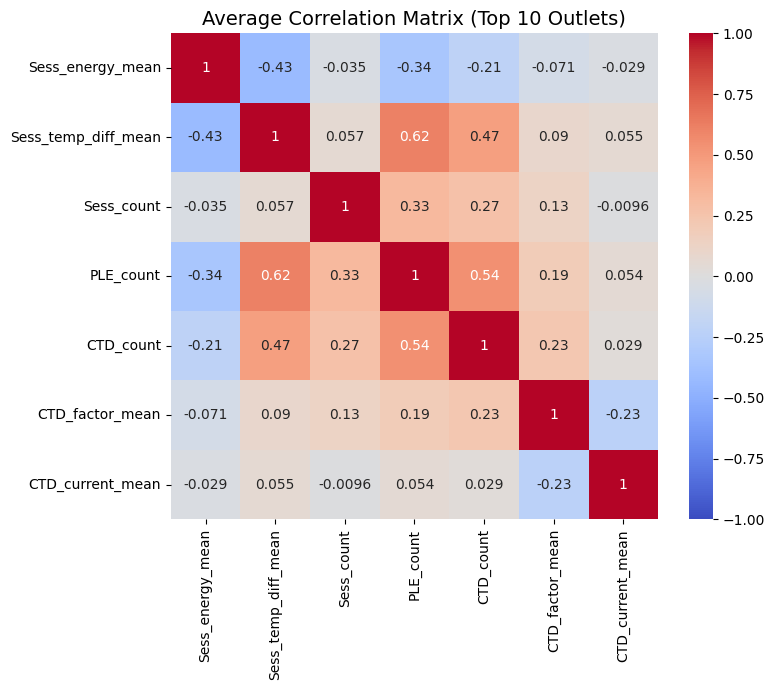

✅ Global average correlation matrix for Top 10 outlets saved as PNG + CSV


In [92]:
# 📁 Define output directory
output_dir_corr = "../plots_correlation"
os.makedirs(output_dir_corr, exist_ok=True)

# 🏆 Top 10 charger-outlet pairs to keep
top10_outlets = [
    ("mtdGiB", 1),
    ("Q2MW2c", 2),
    ("mtdGiB", 2),
    ("D1HnIC", 1),
    ("Q2MW2c", 1),
    ("mgibgC", 2),
    ("OFNgi3", 2),
    ("h37RLm", 2),
    ("DqQLib", 2),
    ("rn5pA9", 1)
]

# 🧰 Collect correlation matrices
corr_matrices = []

for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    if (charger, outlet) not in top10_outlets:
        continue  # skip others
    
    df = df[features].dropna(how="all")
    if df.empty:
        continue
    
    corr_matrices.append(df.corr().values)

# 📊 Average correlation matrix
if corr_matrices:
    avg_corr = np.nanmean(corr_matrices, axis=0)  # element-wise mean
    avg_corr_df = pd.DataFrame(avg_corr, index=features, columns=features)

    # 🎨 Global heatmap
    plt.figure(figsize=(8, 7))
    sns.heatmap(avg_corr_df, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Average Correlation Matrix (Top 10 Outlets)", fontsize=14)
    plt.tight_layout()

    # 💾 Save global plot
    plt.savefig(os.path.join(output_dir_corr, "Global_Average_Correlation_Top10.png"), dpi=150)
    plt.show()

    # 📑 Optional: Save as CSV for reporting
    avg_corr_df.to_csv(os.path.join(output_dir_corr, "Global_Average_Correlation_Top10.csv"))

    print("✅ Global average correlation matrix for Top 10 outlets saved as PNG + CSV")
else:
    print("⚠️ No correlation data available for Top 10 outlets")


### Step1: Focus only on Interpretable Signals(features)

In [93]:
features = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count", "CTD_count", "CLG_count"
]


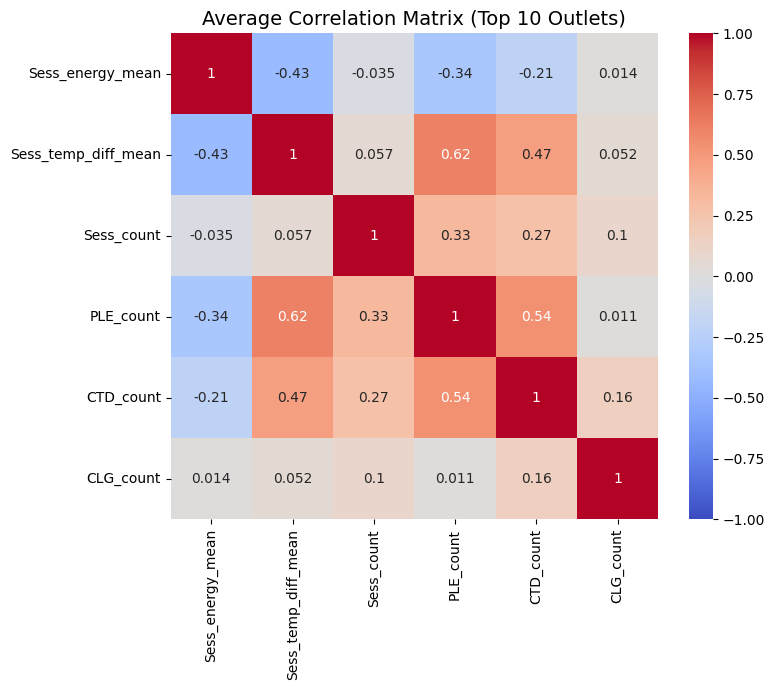

✅ Global average correlation matrix for Top 10 outlets saved as PNG + CSV


In [94]:
# 📁 Define output directory
output_dir_corr = "../plots_correlation"
os.makedirs(output_dir_corr, exist_ok=True)

# 🏆 Top 10 charger-outlet pairs to keep
top10_outlets = [
    ("mtdGiB", 1),
    ("Q2MW2c", 2),
    ("mtdGiB", 2),
    ("D1HnIC", 1),
    ("Q2MW2c", 1),
    ("mgibgC", 2),
    ("OFNgi3", 2),
    ("h37RLm", 2),
    ("DqQLib", 2),
    ("rn5pA9", 1)
]

# 🧰 Collect correlation matrices
corr_matrices = []

for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    if (charger, outlet) not in top10_outlets:
        continue  # skip others
    
    df = df[features].dropna(how="all")
    if df.empty:
        continue
    
    corr_matrices.append(df.corr().values)

# 📊 Average correlation matrix
if corr_matrices:
    avg_corr = np.nanmean(corr_matrices, axis=0)  # element-wise mean
    avg_corr_df = pd.DataFrame(avg_corr, index=features, columns=features)

    # 🎨 Global heatmap
    plt.figure(figsize=(8, 7))
    sns.heatmap(avg_corr_df, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Average Correlation Matrix (Top 10 Outlets)", fontsize=14)
    plt.tight_layout()

    # 💾 Save global plot
    plt.savefig(os.path.join(output_dir_corr, "Global_Average_Correlation_Top10.png"), dpi=150)
    plt.show()

    # 📑 Optional: Save as CSV for reporting
    avg_corr_df.to_csv(os.path.join(output_dir_corr, "Global_Average_Correlation_Top10.csv"))

    print("✅ Global average correlation matrix for Top 10 outlets saved as PNG + CSV")
else:
    print("⚠️ No correlation data available for Top 10 outlets")


### Step 2: Lagged Correlation Analysis

- Function

In [95]:
def prep_daily(df, freq='D'):
    """
    Ensure a continuous daily index per outlet; fill missing days.
    Counts -> fill 0 ; temperatures -> forward-fill then back-fill if needed.
    """
    df = df.sort_values('day').copy()
    # make sure 'day' is datetime and set as index
    df['day'] = pd.to_datetime(df['day'])
    df = df.set_index('day')

    # full daily range
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq=freq)
    df = df.reindex(full_idx)

    # sensible filling
    if 'PLE_count' in df:
        df['PLE_count'] = df['PLE_count'].fillna(0)
    if 'Sess_count' in df:
        df['Sess_count'] = df['Sess_count'].fillna(0)

    for col in ['Sess_temp_diff_mean', 'CTD_count', 'Sess_energy_mean']:
        if col in df:
            df[col] = df[col].ffill().bfill()

    df.index.name = 'day'
    return df

def lag_corr(df, x_col, y_col, max_lag=30):
    """
    Compute Pearson correlation between x_col (shifted by +lag) and y_col.
    Positive lag => x leads y by 'lag' days.
    Returns DataFrame with columns: lag, corr.
    """
    out = []
    for lag in range(0, max_lag + 1):
        x = df[x_col].shift(lag)
        y = df[y_col]
        # drop rows with NaNs caused by shift
        aligned = pd.concat([x, y], axis=1).dropna()
        if len(aligned) >= 5:  # need some data
            r = aligned[x_col].corr(aligned[y_col])
        else:
            r = np.nan
        out.append((lag, r))
    res = pd.DataFrame(out, columns=['lag', 'corr'])
    # best positive leading lag
    best = res.loc[res['corr'].idxmax()]
    return res, best


- Visualization for one outlet!

📌 mtdGiB – Outlet 1
   • Best lag (Sess_temp_diff_mean ➜ PLE): 0 days, r = 0.600
   • Best lag (CTD_count       ➜ PLE): 0 days, r = 0.402


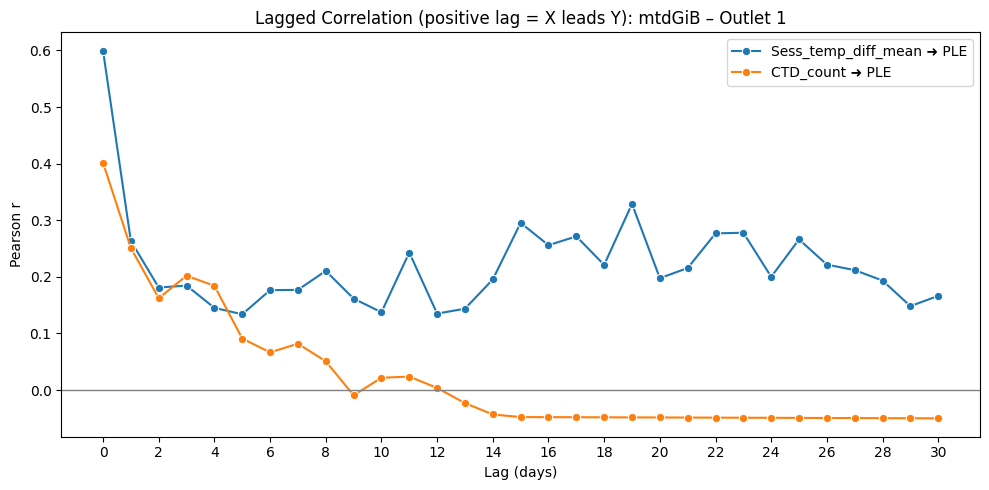

In [96]:
# === Choose outlet ===
charger = "mtdGiB"
outlet = 1

# Filter & prep
df0 = outlet_timeline[(outlet_timeline['@logStream'] == charger) &
                      (outlet_timeline['outlet'] == outlet)].copy()

df1 = prep_daily(df0[['day','PLE_count','Sess_temp_diff_mean','CTD_count','Sess_count','Sess_energy_mean']])

# ---- Compute lagged correlations (temp → PLE) ----
max_lag_days = 30
corr_sess, best_sess = lag_corr(df1, 'Sess_temp_diff_mean', 'PLE_count', max_lag=max_lag_days)
corr_ctd,  best_ctd  = lag_corr(df1, 'CTD_count',        'PLE_count', max_lag=max_lag_days)

print(f"📌 {charger} – Outlet {outlet}")
print(f"   • Best lag (Sess_temp_diff_mean ➜ PLE): {int(best_sess['lag'])} days, r = {best_sess['corr']:.3f}")
print(f"   • Best lag (CTD_count       ➜ PLE): {int(best_ctd['lag'])} days, r = {best_ctd['corr']:.3f}")

# ---- Visualize ----
plt.figure(figsize=(10,5))
sns.lineplot(x='lag', y='corr', data=corr_sess, marker='o', label='Sess_temp_diff_mean ➜ PLE')
sns.lineplot(x='lag', y='corr', data=corr_ctd,  marker='o', label='CTD_count ➜ PLE')
plt.axhline(0, color='grey', lw=1)
plt.title(f'Lagged Correlation (positive lag = X leads Y): {charger} – Outlet {outlet}')
plt.xlabel('Lag (days)')
plt.ylabel('Pearson r')
plt.xticks(range(0, max_lag_days+1, 2))
plt.legend()
plt.tight_layout()
plt.show()


In [97]:
# --- helper: prepare daily data (same as before, shown for completeness) ---
def prep_daily(df):
    d = df.copy()
    d = d.sort_values("day")
    # keep only columns we actually use
    keep = ['day','PLE_count','Sess_temp_diff_mean','CTD_count','Sess_count','Sess_energy_mean']
    d = d[ [c for c in keep if c in d.columns] ]
    # aggregate per day if needed
    d = d.groupby('day', as_index=False).agg({
        'PLE_count':'sum',
        'Sess_temp_diff_mean':'mean',
        'CTD_count':'mean',
        'Sess_count':'sum',
        'Sess_energy_mean':'mean'
    })
    return d

# --- SAFE lag correlation ---
def lag_corr(df, x_col, y_col, max_lag=30, min_points=5):
    """
    Compute Pearson r between x_col (leading) and y_col over lags 0..max_lag.
    Returns (DataFrame with columns ['lag','corr'], 'best' Series with keys {'lag','corr'}).
    If no valid correlations, best = {'lag': NaN, 'corr': NaN}.
    """
    # keep rows where x and y exist
    base = df[[x_col, y_col]].dropna()
    out = []

    for lag in range(0, max_lag + 1):
        tmp = base.copy()
        # X leads Y by 'lag' days ==> shift Y backwards
        tmp[y_col] = tmp[y_col].shift(-lag)
        tmp = tmp.dropna()
        if len(tmp) >= min_points:
            r = tmp[x_col].corr(tmp[y_col])
        else:
            r = np.nan
        out.append((lag, r))

    res = pd.DataFrame(out, columns=['lag', 'corr'])

    valid = res['corr'].dropna()
    if valid.empty:
        best = pd.Series({'lag': np.nan, 'corr': np.nan}, index=['lag','corr'])
    else:
        best = res.loc[valid.idxmax()]

    return res, best

# --- utility to extract safe scalar values from the 'best' Series ---
def safe_best_numbers(best_row):
    lag = best_row.get('lag', np.nan)
    corr = best_row.get('corr', np.nan)
    lag = int(lag) if pd.notna(lag) else np.nan
    corr = float(corr) if pd.notna(corr) else np.nan
    return lag, corr

# ================= SCAN ALL CHARGER–OUTLET PAIRS =================
scan_rows = []
max_lag = 30

for (ch, out), d0 in outlet_timeline.groupby(["@logStream", "outlet"]):
    # subset to needed columns; skip empty
    need_cols = ['day','PLE_count','Sess_temp_diff_mean','CTD_count','Sess_count','Sess_energy_mean']
    d0 = d0[[c for c in need_cols if c in d0.columns]].copy()
    if d0.empty:
        continue

    d1 = prep_daily(d0)

    corr_sess, best_sess = lag_corr(d1, 'Sess_temp_diff_mean', 'PLE_count', max_lag=max_lag)
    corr_ctd,  best_ctd  = lag_corr(d1, 'CTD_count',        'PLE_count', max_lag=max_lag)

    bestlag_sess, bestcorr_sess = safe_best_numbers(best_sess)
    bestlag_ctd,  bestcorr_ctd  = safe_best_numbers(best_ctd)

    scan_rows.append({
        'Charger': ch, 'Outlet': out,
        'BestLag_SessTemp': bestlag_sess, 'BestCorr_SessTemp': bestcorr_sess,
        'BestLag_CTDTemp':  bestlag_ctd,  'BestCorr_CTDTemp':  bestcorr_ctd
    })

rank_df = pd.DataFrame(scan_rows)
rank_df = (
    rank_df
    .dropna(subset=['BestCorr_SessTemp','BestCorr_CTDTemp'], how='all')
    .sort_values(['BestCorr_SessTemp','BestCorr_CTDTemp'], ascending=False)
    .reset_index(drop=True)
)

rank_df.head(20)


c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-p

,Charger,Outlet,BestLag_SessTemp,BestCorr_SessTemp,BestLag_CTDTemp,BestCorr_CTDTemp
0,Q2MW2c,2,0.0,0.782591,0.0,0.860917
1,DqQLib,2,0.0,0.766091,0.0,0.765273
2,OFNgi3,2,0.0,0.721916,0.0,0.796835
3,mgibgC,2,0.0,0.690813,0.0,0.809963
4,rn5pA9,1,0.0,0.640083,0.0,0.469681
5,h37RLm,2,0.0,0.626846,0.0,0.849484
6,mtdGiB,2,0.0,0.622221,27.0,-0.017744
7,h37RLm,1,0.0,0.607359,0.0,0.844717
8,mtdGiB,1,0.0,0.605400,0.0,0.400297
9,aJbfMb,1,0.0,0.582984,0.0,0.884660


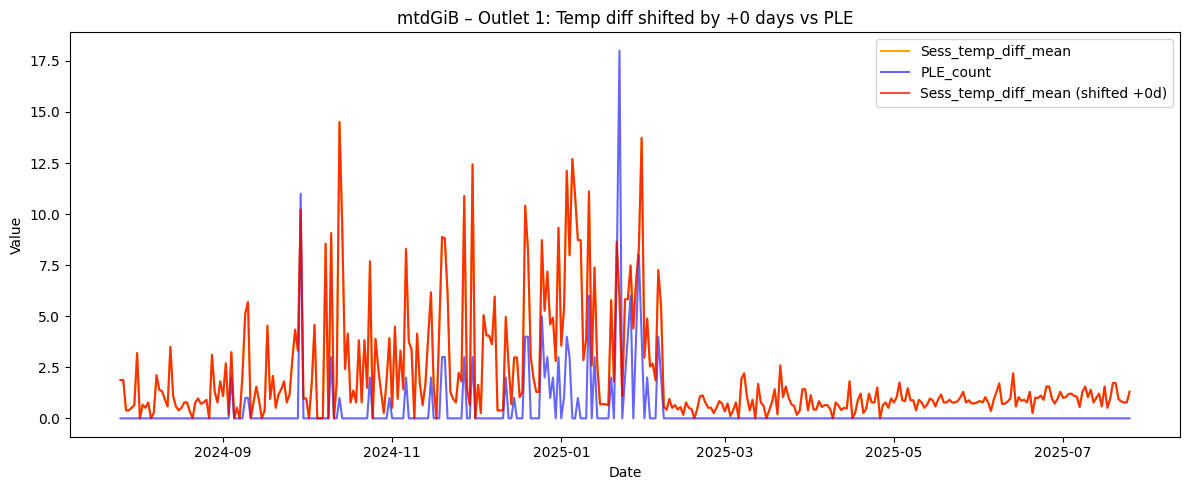

In [98]:
best_lag = int(best_sess.lag)  # from step 2
plt.figure(figsize=(12,5))
plt.plot(df1.index, df1['Sess_temp_diff_mean'], label='Sess_temp_diff_mean', color='orange')
plt.plot(df1.index, df1['PLE_count'], label='PLE_count', color='blue', alpha=0.6)
# Shift temp by best_lag forward to visualize alignment with PLE
plt.plot(df1.index, df1['Sess_temp_diff_mean'].shift(best_lag), 
         label=f'Sess_temp_diff_mean (shifted +{best_lag}d)', color='red', alpha=0.7)
plt.legend()
plt.title(f"{charger} – Outlet {outlet}: Temp diff shifted by +{best_lag} days vs PLE")
plt.xlabel("Date"); plt.ylabel("Value"); plt.tight_layout(); plt.show()


 #### 21) Correlation Matrix for One Charger-Outlet

How to judge the numbers

0.6 to 1.0 (or -0.6 to -1.0) → strong correlation.

0.4 to 0.6 (or -0.4 to -0.6) → moderate correlation.

0.2 to 0.4 (or -0.2 to -0.4) → weak correlation.

0.0 to 0.2 → very little or no correlation.

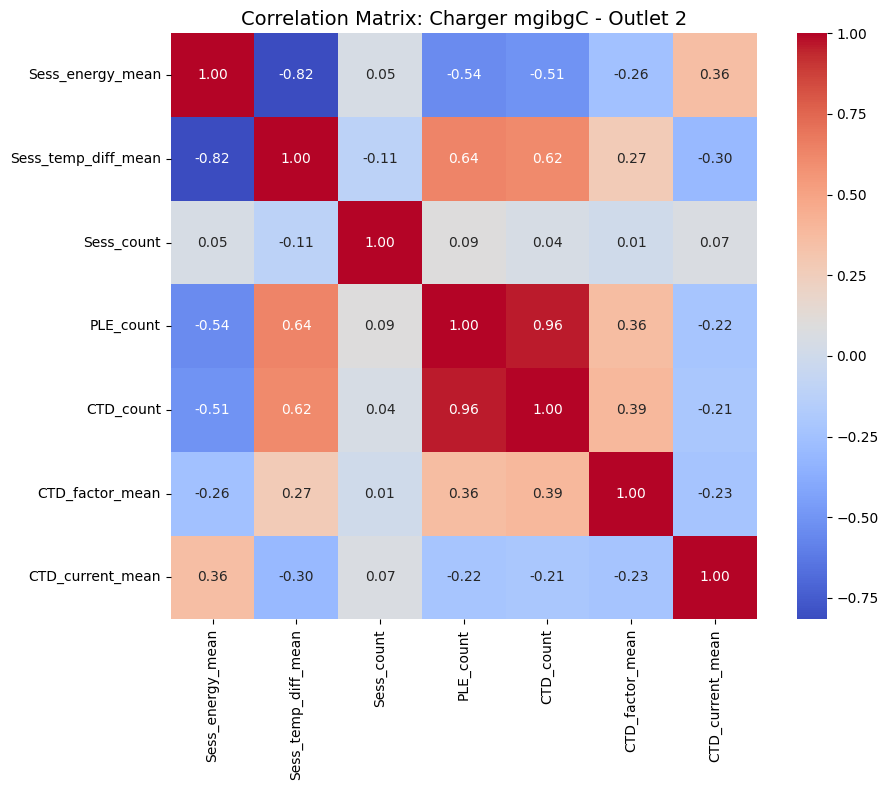

In [99]:
# --- Correlation Matrix for One Charger-Outlet ---
# 🎯 Filter data for the charger-outlet of interest
charger = "mgibgC"
outlet = 2
df = outlet_timeline[
    (outlet_timeline["@logStream"] == charger) &
    (outlet_timeline["outlet"] == outlet)
].copy()

# 🧹 Keep only numeric feature columns
numeric_cols = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count",
    "CTD_count", "CTD_factor_mean", "CTD_current_mean",
    "CLG_temp1_mean", "CLG_temp2_mean", "CLG_diff_mean", "CLG_current_mean"
]

# Drop columns with all NaNs
df_num = df[numeric_cols].dropna(axis=1, how="all")

# Drop rows with too many NaNs (optional, keeps correlations valid)
df_num = df_num.dropna(how="any")

# 📊 Compute correlation matrix
corr = df_num.corr(method="pearson")

# 🔥 Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title(f"Correlation Matrix: Charger {charger} - Outlet {outlet}", fontsize=14)
plt.tight_layout()
plt.show()


#### Correlation Matrix for all Chargers-Outlets

In [100]:
# 📁 Output folder
output_dir_corr = "../plots_outlet_correlations"
os.makedirs(output_dir_corr, exist_ok=True)

# 🎯 Features to analyze
features = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count", "CTD_count", "CTD_factor_mean", "CTD_current_mean"
]

# 🔄 Iterate over each charger-outlet
for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    df = df[features].dropna(how="all")  # keep only relevant columns

    if df.empty:
        continue  # skip if no data

    # 📊 Correlation matrix
    corr = df.corr()

    # 🎨 Plot heatmap
    plt.figure(figsize=(8, 7))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix: {charger} - Outlet {outlet}", fontsize=14)

    # 💾 Save each plot
    filename = f"{charger}_Outlet{outlet}_correlation.png".replace("/", "_")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_corr, filename), dpi=150)
    plt.close()

print(f"✅ Correlation matrices saved in {output_dir_corr}")


✅ Correlation matrices saved in ../plots_outlet_correlations


#### Export Correlation Values for All Chargers/Outlets
- which chargers/outlets are worth keeping

In [101]:
# 🎯 Features we care about
features = [
    "Sess_energy_mean", "Sess_temp_diff_mean", "Sess_count",
    "PLE_count", "CTD_count", "CTD_factor_mean", "CTD_current_mean"
]

# 📊 Store results here
correlation_records = []

# 🔄 Iterate through charger-outlet pairs
for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    df = df[features].dropna(how="all")  # keep only numeric data

    if df.shape[0] < 10:  
        continue  # skip outlets with too few rows to be meaningful

    # Compute correlation matrix
    corr = df.corr()

    # Flatten into long format for CSV
    for row in corr.index:
        for col in corr.columns:
            if row != col:  # skip self-correlation (always 1.0)
                correlation_records.append({
                    "Charger": charger,
                    "Outlet": outlet,
                    "Feature1": row,
                    "Feature2": col,
                    "Correlation": corr.loc[row, col]
                })

# 📂 Convert to DataFrame
corr_df = pd.DataFrame(correlation_records)

# 💾 Save to CSV
output_csv = "../correlations_all_chargers.csv"
corr_df.to_csv(output_csv, index=False)

print(f"✅ Correlations exported to {output_csv}")


✅ Correlations exported to ../correlations_all_chargers.csv


#### Process the outcome:
 Strategy:
 1. Group by Charger+Outlet
 2. For each group, calculate the strongest absolute correlation (max |r|)
 3. Rank chargers by that score to see which ones show meaningful correlations

In [102]:
# Add combined identifier
corr_df["Charger_Outlet"] = corr_df["Charger"] + "_O" + corr_df["Outlet"].astype(str)

# Compute max absolute correlation per charger-outlet
summary = (
    corr_df.groupby("Charger_Outlet")["Correlation"]
    .apply(lambda x: x.abs().max())
    .reset_index()
    .rename(columns={"Correlation": "MaxAbsCorrelation"})
    .sort_values(by="MaxAbsCorrelation", ascending=False)
)

summary.head(15)


,Charger_Outlet,MaxAbsCorrelation
11,aJbfMb_O1,0.884660
7,Q2MW2c_O2,0.860917
14,h37RLm_O2,0.849484
13,h37RLm_O1,0.844717
16,mgibgC_O2,0.809963
6,Q2MW2c_O1,0.798666
5,OFNgi3_O2,0.796835
3,DqQLib_O2,0.766091
2,DqQLib_O1,0.715816
23,zhSxBz_O2,0.686245


#### Global average correlation matrix (Average over top 10)

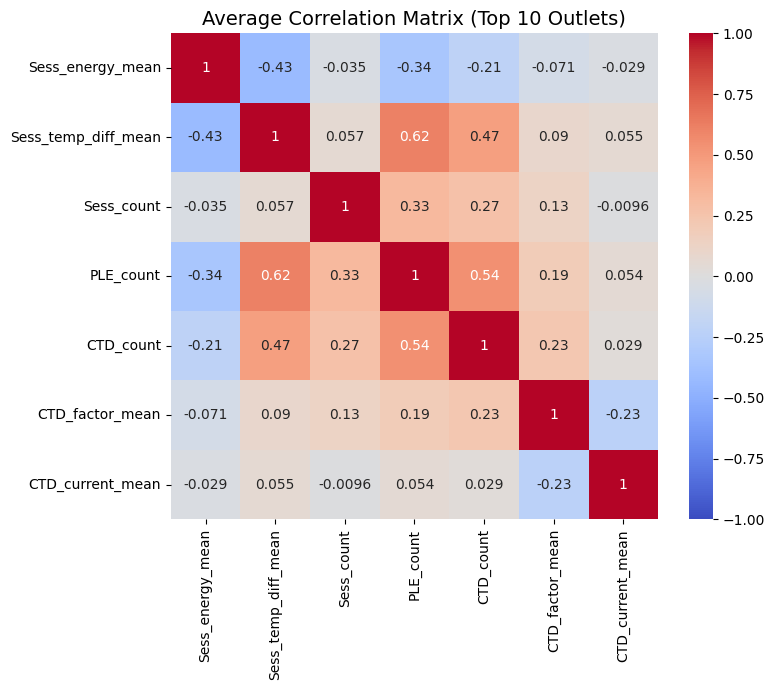

✅ Global average correlation matrix for Top 10 outlets saved as PNG + CSV


In [103]:
# 📁 Define output directory
output_dir_corr = "../plots_correlation"
os.makedirs(output_dir_corr, exist_ok=True)

# 🏆 Top 10 charger-outlet pairs to keep
top10_outlets = [
    ("mtdGiB", 1),
    ("Q2MW2c", 2),
    ("mtdGiB", 2),
    ("D1HnIC", 1),
    ("Q2MW2c", 1),
    ("mgibgC", 2),
    ("OFNgi3", 2),
    ("h37RLm", 2),
    ("DqQLib", 2),
    ("rn5pA9", 1)
]

# 🧰 Collect correlation matrices
corr_matrices = []

for (charger, outlet), df in outlet_timeline.groupby(["@logStream", "outlet"]):
    if (charger, outlet) not in top10_outlets:
        continue  # skip others
    
    df = df[features].dropna(how="all")
    if df.empty:
        continue
    
    corr_matrices.append(df.corr().values)

# 📊 Average correlation matrix
if corr_matrices:
    avg_corr = np.nanmean(corr_matrices, axis=0)  # element-wise mean
    avg_corr_df = pd.DataFrame(avg_corr, index=features, columns=features)

    # 🎨 Global heatmap
    plt.figure(figsize=(8, 7))
    sns.heatmap(avg_corr_df, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Average Correlation Matrix (Top 10 Outlets)", fontsize=14)
    plt.tight_layout()

    # 💾 Save global plot
    plt.savefig(os.path.join(output_dir_corr, "Global_Average_Correlation_Top10.png"), dpi=150)
    plt.show()

    # 📑 Optional: Save as CSV for reporting
    avg_corr_df.to_csv(os.path.join(output_dir_corr, "Global_Average_Correlation_Top10.csv"))

    print("✅ Global average correlation matrix for Top 10 outlets saved as PNG + CSV")
else:
    print("⚠️ No correlation data available for Top 10 outlets")


#### Next steps:
- Step1: Feature Selection

        Keep: Sess_temp_diff_mean, CTD_count, PLE_count, Sess_count, Sess_energy_mean.

        Drop (or deprioritize): CTD_factor_mean, CTD_current_mean.

        This reduces noise and focuses on interpretable signals.

- Step2: Lagged Correlation Analysis

        Check if temperature rise happens days/weeks before PLE spikes.

        That would make temp diff a leading indicator for predictive maintenance.

- Step3: Cluster Outlets by Correlation Profile

        Some outlets may show stronger temp ↔ PLE than others.

        Grouping them could reveal whether certain hardware (chargers/outlets) are more sensitive to overheating.

- Step4: considering the duration as a feature !

        long or short duration effect the temp? 

        and questions like that!

- Step5: Early Predictive Model Prep

        Build a baseline regression or classification:

        Inputs = Sess_temp_diff_mean, Sess_count.

        Target = PLE_count > 0 (failure day).

        This would quantify predictive power.

### Step1: Focus only on Interpretable Signals(features)

- Visualization for one outlet!

📌 mtdGiB – Outlet 1
   • Best lag (Sess_temp_diff_mean ➜ PLE): 0 days, r = 0.605
   • Best lag (CTD_count       ➜ PLE): 0 days, r = 0.400


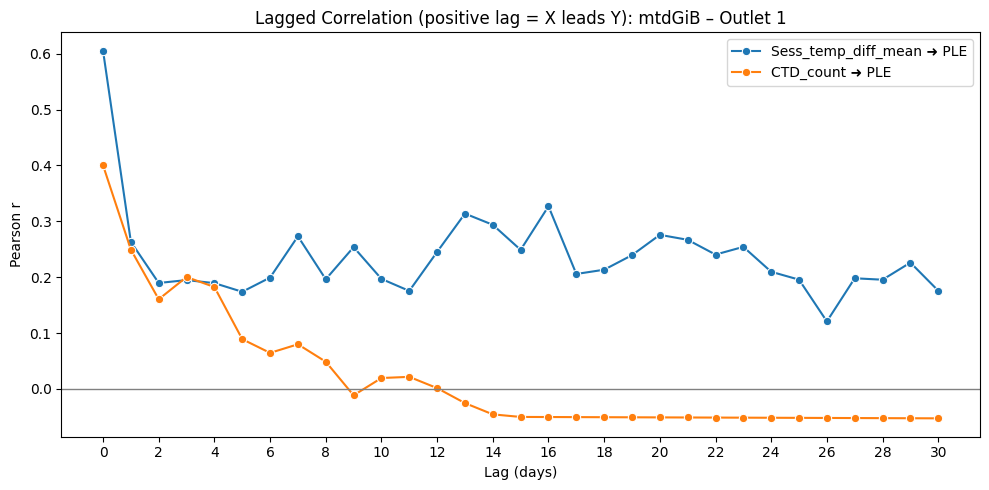

In [104]:
# === Choose outlet ===
charger = "mtdGiB"
outlet = 1

# Filter & prep
df0 = outlet_timeline[(outlet_timeline['@logStream'] == charger) &
                      (outlet_timeline['outlet'] == outlet)].copy()

df1 = prep_daily(df0[['day','PLE_count','Sess_temp_diff_mean','CTD_count','Sess_count','Sess_energy_mean']])

# ---- Compute lagged correlations (temp → PLE) ----
max_lag_days = 30
corr_sess, best_sess = lag_corr(df1, 'Sess_temp_diff_mean', 'PLE_count', max_lag=max_lag_days)
corr_ctd,  best_ctd  = lag_corr(df1, 'CTD_count',        'PLE_count', max_lag=max_lag_days)

print(f"📌 {charger} – Outlet {outlet}")
print(f"   • Best lag (Sess_temp_diff_mean ➜ PLE): {int(best_sess['lag'])} days, r = {best_sess['corr']:.3f}")
print(f"   • Best lag (CTD_count       ➜ PLE): {int(best_ctd['lag'])} days, r = {best_ctd['corr']:.3f}")

# ---- Visualize ----
plt.figure(figsize=(10,5))
sns.lineplot(x='lag', y='corr', data=corr_sess, marker='o', label='Sess_temp_diff_mean ➜ PLE')
sns.lineplot(x='lag', y='corr', data=corr_ctd,  marker='o', label='CTD_count ➜ PLE')
plt.axhline(0, color='grey', lw=1)
plt.title(f'Lagged Correlation (positive lag = X leads Y): {charger} – Outlet {outlet}')
plt.xlabel('Lag (days)')
plt.ylabel('Pearson r')
plt.xticks(range(0, max_lag_days+1, 2))
plt.legend()
plt.tight_layout()
plt.show()


In [105]:
# --- helper: prepare daily data (same as before, shown for completeness) ---
def prep_daily(df):
    d = df.copy()
    d = d.sort_values("day")
    # keep only columns we actually use
    keep = ['day','PLE_count','Sess_temp_diff_mean','CTD_count','Sess_count','Sess_energy_mean']
    d = d[ [c for c in keep if c in d.columns] ]
    # aggregate per day if needed
    d = d.groupby('day', as_index=False).agg({
        'PLE_count':'sum',
        'Sess_temp_diff_mean':'mean',
        'CTD_count':'mean',
        'Sess_count':'sum',
        'Sess_energy_mean':'mean'
    })
    return d

# --- SAFE lag correlation ---
def lag_corr(df, x_col, y_col, max_lag=30, min_points=5):
    """
    Compute Pearson r between x_col (leading) and y_col over lags 0..max_lag.
    Returns (DataFrame with columns ['lag','corr'], 'best' Series with keys {'lag','corr'}).
    If no valid correlations, best = {'lag': NaN, 'corr': NaN}.
    """
    # keep rows where x and y exist
    base = df[[x_col, y_col]].dropna()
    out = []

    for lag in range(0, max_lag + 1):
        tmp = base.copy()
        # X leads Y by 'lag' days ==> shift Y backwards
        tmp[y_col] = tmp[y_col].shift(-lag)
        tmp = tmp.dropna()
        if len(tmp) >= min_points:
            r = tmp[x_col].corr(tmp[y_col])
        else:
            r = np.nan
        out.append((lag, r))

    res = pd.DataFrame(out, columns=['lag', 'corr'])

    valid = res['corr'].dropna()
    if valid.empty:
        best = pd.Series({'lag': np.nan, 'corr': np.nan}, index=['lag','corr'])
    else:
        best = res.loc[valid.idxmax()]

    return res, best

# --- utility to extract safe scalar values from the 'best' Series ---
def safe_best_numbers(best_row):
    lag = best_row.get('lag', np.nan)
    corr = best_row.get('corr', np.nan)
    lag = int(lag) if pd.notna(lag) else np.nan
    corr = float(corr) if pd.notna(corr) else np.nan
    return lag, corr

# ================= SCAN ALL CHARGER–OUTLET PAIRS =================
scan_rows = []
max_lag = 30

for (ch, out), d0 in outlet_timeline.groupby(["@logStream", "outlet"]):
    # subset to needed columns; skip empty
    need_cols = ['day','PLE_count','Sess_temp_diff_mean','CTD_count','Sess_count','Sess_energy_mean']
    d0 = d0[[c for c in need_cols if c in d0.columns]].copy()
    if d0.empty:
        continue

    d1 = prep_daily(d0)

    corr_sess, best_sess = lag_corr(d1, 'Sess_temp_diff_mean', 'PLE_count', max_lag=max_lag)
    corr_ctd,  best_ctd  = lag_corr(d1, 'CTD_count',        'PLE_count', max_lag=max_lag)

    bestlag_sess, bestcorr_sess = safe_best_numbers(best_sess)
    bestlag_ctd,  bestcorr_ctd  = safe_best_numbers(best_ctd)

    scan_rows.append({
        'Charger': ch, 'Outlet': out,
        'BestLag_SessTemp': bestlag_sess, 'BestCorr_SessTemp': bestcorr_sess,
        'BestLag_CTDTemp':  bestlag_ctd,  'BestCorr_CTDTemp':  bestcorr_ctd
    })

rank_df = pd.DataFrame(scan_rows)
rank_df = (
    rank_df
    .dropna(subset=['BestCorr_SessTemp','BestCorr_CTDTemp'], how='all')
    .sort_values(['BestCorr_SessTemp','BestCorr_CTDTemp'], ascending=False)
    .reset_index(drop=True)
)

rank_df.head(20)


c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\z0054bay\OneDrive - Siemens AG\Projects\.venv\Lib\site-p

,Charger,Outlet,BestLag_SessTemp,BestCorr_SessTemp,BestLag_CTDTemp,BestCorr_CTDTemp
0,Q2MW2c,2,0.0,0.782591,0.0,0.860917
1,DqQLib,2,0.0,0.766091,0.0,0.765273
2,OFNgi3,2,0.0,0.721916,0.0,0.796835
3,mgibgC,2,0.0,0.690813,0.0,0.809963
4,rn5pA9,1,0.0,0.640083,0.0,0.469681
5,h37RLm,2,0.0,0.626846,0.0,0.849484
6,mtdGiB,2,0.0,0.622221,27.0,-0.017744
7,h37RLm,1,0.0,0.607359,0.0,0.844717
8,mtdGiB,1,0.0,0.605400,0.0,0.400297
9,aJbfMb,1,0.0,0.582984,0.0,0.884660


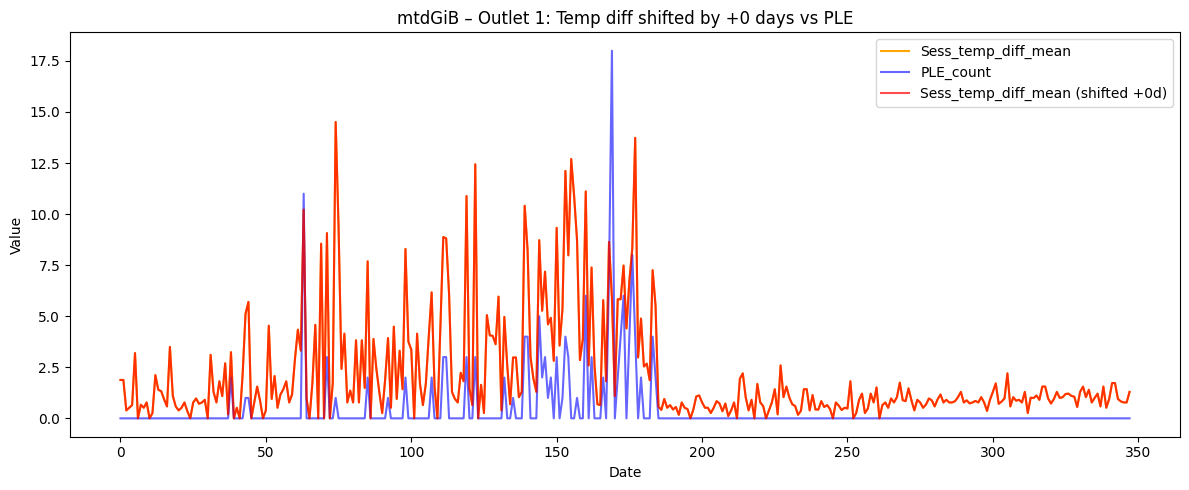

In [106]:
best_lag = int(best_sess.lag)  # from step 2
plt.figure(figsize=(12,5))
plt.plot(df1.index, df1['Sess_temp_diff_mean'], label='Sess_temp_diff_mean', color='orange')
plt.plot(df1.index, df1['PLE_count'], label='PLE_count', color='blue', alpha=0.6)
# Shift temp by best_lag forward to visualize alignment with PLE
plt.plot(df1.index, df1['Sess_temp_diff_mean'].shift(best_lag), 
         label=f'Sess_temp_diff_mean (shifted +{best_lag}d)', color='red', alpha=0.7)
plt.legend()
plt.title(f"{charger} – Outlet {outlet}: Temp diff shifted by +{best_lag} days vs PLE")
plt.xlabel("Date"); plt.ylabel("Value"); plt.tight_layout(); plt.show()
